<a href="https://colab.research.google.com/github/RKlavins/Markets-Strategies/blob/main/Monte_Carlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Price paths shape: (253, 10000)
  Rows = 253 time steps
  Cols = 10000 simulations

Final price statistics across 10000 simulations:
  Mean:   $104.96
  Median: $102.98
  Std:    $21.11
  Min:    $51.59
  Max:    $216.40


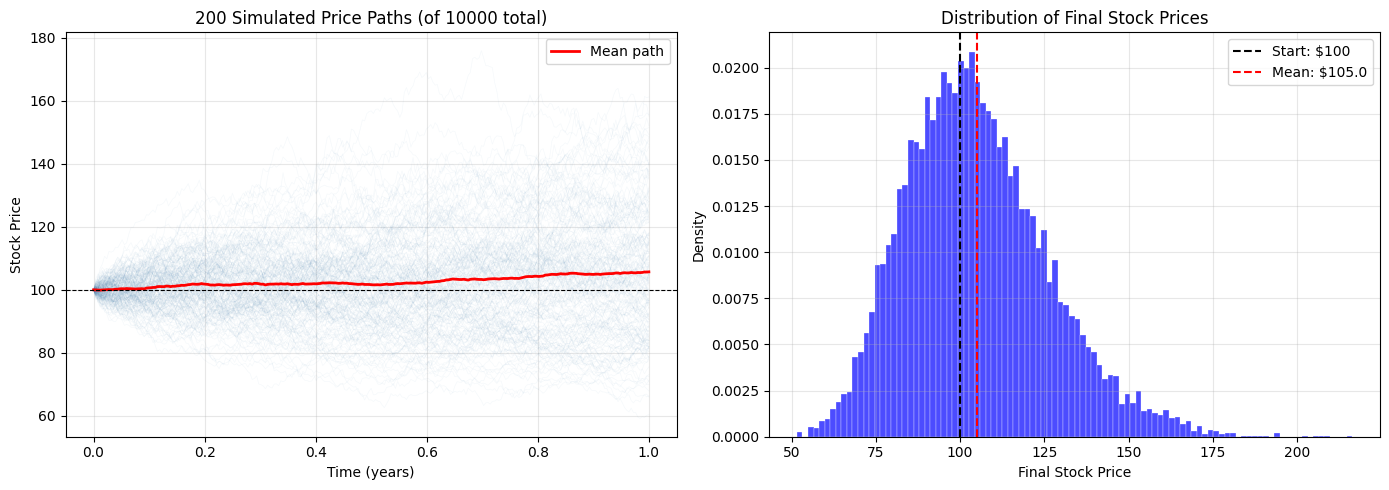

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# ============================================================
# Part 1 — Simulate stock price paths (Geometric Brownian Motion)
# ============================================================

np.random.seed(42)

# Parameters
S0    = 100    # current stock price
r     = 0.05   # risk-free rate
sigma = 0.20   # volatility
T     = 1.0    # time to expiry in years
n_steps  = 252    # daily steps
n_sims   = 10000  # number of simulations

dt = T / n_steps

# Simulate paths
# GBM: S(t+dt) = S(t) * exp((r - 0.5*sigma^2)*dt + sigma*sqrt(dt)*Z)
# where Z ~ N(0,1)

Z = np.random.standard_normal((n_steps, n_sims))

# Build price paths step by step
daily_returns = np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
price_paths   = S0 * np.cumprod(daily_returns, axis=0)

# Add starting price row
price_paths = np.vstack([np.full(n_sims, S0), price_paths])

print(f"Price paths shape: {price_paths.shape}")
print(f"  Rows = {price_paths.shape[0]} time steps")
print(f"  Cols = {price_paths.shape[1]} simulations")
print(f"\nFinal price statistics across {n_sims} simulations:")
final_prices = price_paths[-1, :]
print(f"  Mean:   ${final_prices.mean():.2f}")
print(f"  Median: ${np.median(final_prices):.2f}")
print(f"  Std:    ${final_prices.std():.2f}")
print(f"  Min:    ${final_prices.min():.2f}")
print(f"  Max:    ${final_prices.max():.2f}")

# --- Plot sample paths ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Show first 200 paths
time_axis = np.linspace(0, T, n_steps + 1)
for i in range(200):
    axes[0].plot(time_axis, price_paths[:, i],
                 color='steelblue', alpha=0.05, linewidth=0.5)
axes[0].plot(time_axis, price_paths[:, :200].mean(axis=1),
             color='red', linewidth=2, label='Mean path')
axes[0].axhline(y=S0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title(f'200 Simulated Price Paths (of {n_sims} total)')
axes[0].set_xlabel('Time (years)')
axes[0].set_ylabel('Stock Price')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribution of final prices
axes[1].hist(final_prices, bins=100, color='blue',
             edgecolor='white', linewidth=0.3, density=True, alpha=0.7)
axes[1].axvline(x=S0,  color='black', linewidth=1.5,
                linestyle='--', label=f'Start: ${S0}')
axes[1].axvline(x=final_prices.mean(), color='red', linewidth=1.5,
                linestyle='--', label=f'Mean: ${final_prices.mean():.1f}')
axes[1].set_title('Distribution of Final Stock Prices')
axes[1].set_xlabel('Final Stock Price')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Part 2 — Price options using Monte Carlo
# ============================================================

def monte_carlo_price(S0, K, T, r, sigma,
                      option_type='call',
                      n_sims=100000,
                      n_steps=252):
    """
    Price a European option using Monte Carlo simulation
    """
    dt = T / n_steps

    # Simulate final prices only (we don't need full paths for European options)
    Z            = np.random.standard_normal(n_sims)
    final_prices = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)

    # Calculate payoff
    if option_type == 'call':
        payoffs = np.maximum(final_prices - K, 0)
    else:
        payoffs = np.maximum(K - final_prices, 0)

    # Discount back to present value
    price = np.exp(-r*T) * payoffs.mean()

    # Standard error of the estimate
    std_error = payoffs.std() / np.sqrt(n_sims)
    conf_interval = 1.96 * std_error

    return price, conf_interval

# Black-Scholes for comparison
def bs_price(S, K, T, r, sigma, option_type='call'):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == 'call':
        return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

# --- Compare MC vs BS across strikes ---
S0, T, r, sigma = 100, 0.25, 0.05, 0.20
strikes = np.arange(80, 125, 5)

print("European Call Option Pricing — Monte Carlo vs Black-Scholes")
print("="*65)
print(f"{'Strike':>8} {'BS Price':>10} {'MC Price':>10} {'95% CI':>10} {'Difference':>12}")
print("-"*65)

for K in strikes:
    bs  = bs_price(S0, K, T, r, sigma, 'call')
    mc, ci = monte_carlo_price(S0, K, T, r, sigma, 'call', n_sims=100000)
    diff = mc - bs
    print(f"${K:>7} {bs:>10.4f} {mc:>10.4f}   ±{ci:.4f} {diff:>+12.4f}")

European Call Option Pricing — Monte Carlo vs Black-Scholes
  Strike   BS Price   MC Price     95% CI   Difference
-----------------------------------------------------------------
$     80    21.0213    21.0118   ±0.0624      -0.0095
$     85    16.2039    16.1608   ±0.0610      -0.0430
$     90    11.6701    11.6390   ±0.0573      -0.0311
$     95     7.7144     7.7309   ±0.0508      +0.0165
$    100     4.6150     4.6226   ±0.0414      +0.0076
$    105     2.4779     2.4573   ±0.0310      -0.0206
$    110     1.1911     1.1800   ±0.0213      -0.0112
$    115     0.5137     0.5134   ±0.0137      -0.0003
$    120     0.1998     0.1959   ±0.0083      -0.0038


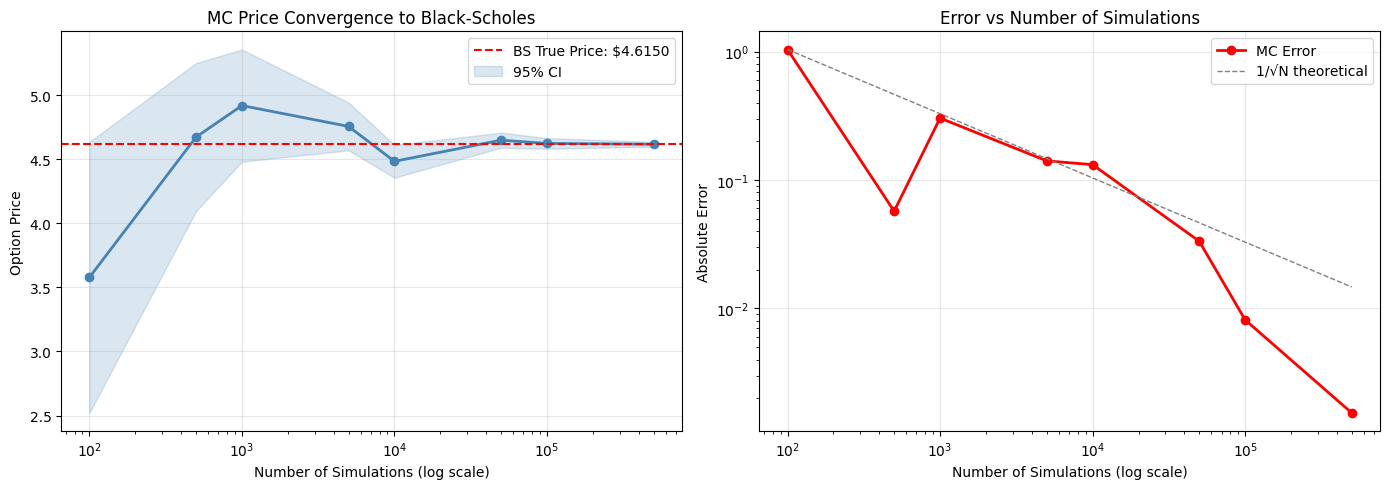

Convergence table:
    Sims   MC Price      Error     95% CI
------------------------------------------
     100     3.5772     1.0378   ±1.0573
     500     4.6721     0.0571   ±0.5781
   1,000     4.9185     0.3035   ±0.4374
   5,000     4.7559     0.1409   ±0.1867
  10,000     4.4834     0.1316   ±0.1280
  50,000     4.6483     0.0333   ±0.0589
 100,000     4.6231     0.0081   ±0.0415
 500,000     4.6165     0.0015   ±0.0185


In [ ]:
# ============================================================
# Part 3 — Convergence analysis
# ============================================================
# How many simulations do you need for accuracy?

K = 100  # ATM option
bs_true = bs_price(S0, K, T, r, sigma, 'call')

sim_counts = [100, 500, 1000, 5000, 10000, 50000, 100000, 500000]
mc_prices  = []
errors     = []
conf_intervals = []

for n in sim_counts:
    price, ci = monte_carlo_price(S0, K, T, r, sigma, 'call', n_sims=n)
    mc_prices.append(price)
    errors.append(abs(price - bs_true))
    conf_intervals.append(ci)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MC price convergence
axes[0].semilogx(sim_counts, mc_prices, 'o-',
                 color='steelblue', linewidth=2, markersize=6)
axes[0].axhline(y=bs_true, color='red', linewidth=1.5,
                linestyle='--', label=f'BS True Price: ${bs_true:.4f}')
axes[0].fill_between(sim_counts,
                     [p - ci for p, ci in zip(mc_prices, conf_intervals)],
                     [p + ci for p, ci in zip(mc_prices, conf_intervals)],
                     alpha=0.2, color='steelblue', label='95% CI')
axes[0].set_title('MC Price Convergence to Black-Scholes')
axes[0].set_xlabel('Number of Simulations (log scale)')
axes[0].set_ylabel('Option Price')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Error convergence
axes[1].loglog(sim_counts, errors, 'o-',
               color='red', linewidth=2, markersize=6, label='MC Error')
axes[1].loglog(sim_counts,
               [errors[0]/np.sqrt(n/sim_counts[0]) for n in sim_counts],
               '--', color='gray', linewidth=1, label='1/√N theoretical')
axes[1].set_title('Error vs Number of Simulations')
axes[1].set_xlabel('Number of Simulations (log scale)')
axes[1].set_ylabel('Absolute Error')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Convergence table:")
print(f"{'Sims':>8} {'MC Price':>10} {'Error':>10} {'95% CI':>10}")
print("-"*42)
for n, p, e, ci in zip(sim_counts, mc_prices, errors, conf_intervals):
    print(f"{n:>8,} {p:>10.4f} {e:>10.4f}   ±{ci:.4f}")

In [ ]:
# ============================================================
# Part 4 — Price exotic options Black-Scholes can't handle
# ============================================================

# Asian option — payoff based on AVERAGE price over the life
# Black-Scholes has no closed form for this
def asian_call_mc(S0, K, T, r, sigma, n_sims=100000, n_steps=252):
    dt = T / n_steps
    Z  = np.random.standard_normal((n_steps, n_sims))

    daily_ret   = np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
    price_paths = S0 * np.cumprod(daily_ret, axis=0)

    # Payoff based on AVERAGE price, not final price
    avg_prices  = price_paths.mean(axis=0)
    payoffs     = np.maximum(avg_prices - K, 0)

    return np.exp(-r*T) * payoffs.mean()

# Barrier option — knocked out if price touches a barrier
def barrier_call_mc(S0, K, T, r, sigma, barrier,
                    n_sims=100000, n_steps=252):
    dt = T / n_steps
    Z  = np.random.standard_normal((n_steps, n_sims))

    daily_ret   = np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
    price_paths = S0 * np.cumprod(daily_ret, axis=0)

    # Option is knocked OUT if price ever goes above barrier
    knocked_out = (price_paths.max(axis=0) >= barrier)
    final_prices = price_paths[-1, :]

    payoffs = np.maximum(final_prices - K, 0)
    payoffs[knocked_out] = 0  # zero payoff if knocked out

    return np.exp(-r*T) * payoffs.mean()

# Lookback option — payoff based on MAXIMUM price achieved
def lookback_call_mc(S0, T, r, sigma, n_sims=100000, n_steps=252):
    dt = T / n_steps
    Z  = np.random.standard_normal((n_steps, n_sims))

    daily_ret   = np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
    price_paths = S0 * np.cumprod(daily_ret, axis=0)

    # Payoff = final price - minimum price achieved (floating strike lookback)
    min_prices  = price_paths.min(axis=0)
    final_prices = price_paths[-1, :]
    payoffs      = np.maximum(final_prices - min_prices, 0)

    return np.exp(-r*T) * payoffs.mean()

# --- Compare all option types ---
S0, K, T, r, sigma = 100, 100, 1.0, 0.05, 0.20
barrier = 120

european   = bs_price(S0, K, T, r, sigma, 'call')
asian      = asian_call_mc(S0, K, T, r, sigma)
barrier_c  = barrier_call_mc(S0, K, T, r, sigma, barrier)
lookback   = lookback_call_mc(S0, T, r, sigma)

print("\nOption Pricing Comparison (S=100, K=100, T=1yr, σ=20%)")
print("="*55)
print(f"European Call (BS):           ${european:.4f}")
print(f"Asian Call (avg price):       ${asian:.4f}")
print(f"Barrier Call (knock-out 120): ${barrier_c:.4f}")
print(f"Lookback Call (float strike): ${lookback:.4f}")
print()
print("Why each differs from European:")
print(f"Asian is cheaper by    ${european-asian:.4f} — averaging reduces volatility exposure")
print(f"Barrier is cheaper by  ${european-barrier_c:.4f} — risk of being knocked out")
print(f"Lookback is pricier by ${lookback-european:.4f} — always buys at the lowest price")


Option Pricing Comparison (S=100, K=100, T=1yr, σ=20%)
European Call (BS):           $10.4506
Asian Call (avg price):       $5.7744
Barrier Call (knock-out 120): $1.3127
Lookback Call (float strike): $16.5261

Why each differs from European:
Asian is cheaper by    $4.6762 — averaging reduces volatility exposure
Barrier is cheaper by  $9.1379 — risk of being knocked out
Lookback is pricier by $6.0755 — always buys at the lowest price


boom next part bitch


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# PROFESSIONAL MONTE CARLO OPTIONS PRICER
# ============================================================

class MonteCarloPricer:
    """
    Professional Monte Carlo option pricer supporting:
    - European calls and puts
    - Asian options (arithmetic and geometric average)
    - Barrier options (knock-in and knock-out)
    - Lookback options
    - Digital/Binary options
    - Portfolio of options

    Features:
    - Antithetic variates variance reduction
    - Confidence intervals
    - Greeks via finite difference
    - Implied volatility extraction
    - Comparison with Black-Scholes where applicable
    """

    def __init__(self, S0, r, sigma, T, n_sims=100000, n_steps=252, seed=42):
        self.S0      = S0
        self.r       = r
        self.sigma   = sigma
        self.T       = T
        self.n_sims  = n_sims
        self.n_steps = n_steps
        self.seed    = seed
        self._paths  = None  # cache paths

    def _simulate_paths(self, antithetic=True):
        """Simulate GBM price paths with optional antithetic variates"""
        np.random.seed(self.seed)
        dt = self.T / self.n_steps

        if antithetic:
            # Generate half the normals then mirror them
            # Reduces variance significantly at no extra cost
            half = self.n_sims // 2
            Z_half = np.random.standard_normal((self.n_steps, half))
            Z      = np.concatenate([Z_half, -Z_half], axis=1)
        else:
            Z = np.random.standard_normal((self.n_steps, self.n_sims))

        # GBM paths
        daily_ret = np.exp(
            (self.r - 0.5*self.sigma**2) * dt +
            self.sigma * np.sqrt(dt) * Z
        )
        paths = self.S0 * np.cumprod(daily_ret, axis=0)
        paths = np.vstack([np.full(paths.shape[1], self.S0), paths])

        return paths

    @property
    def paths(self):
        if self._paths is None:
            self._paths = self._simulate_paths()
        return self._paths

    def _discount(self, payoffs):
        price     = np.exp(-self.r * self.T) * payoffs.mean()
        std_error = payoffs.std() / np.sqrt(len(payoffs))
        ci_95     = 1.96 * std_error
        return price, ci_95

    # ============================================================
    # Option types
    # ============================================================

    def european(self, K, option_type='call'):
        final = self.paths[-1, :]
        if option_type == 'call':
            payoffs = np.maximum(final - K, 0)
        else:
            payoffs = np.maximum(K - final, 0)
        return self._discount(payoffs)

    def asian_arithmetic(self, K, option_type='call'):
        avg = self.paths[1:, :].mean(axis=0)
        if option_type == 'call':
            payoffs = np.maximum(avg - K, 0)
        else:
            payoffs = np.maximum(K - avg, 0)
        return self._discount(payoffs)

    def asian_geometric(self, K, option_type='call'):
        log_avg = np.log(self.paths[1:, :]).mean(axis=0)
        geo_avg = np.exp(log_avg)
        if option_type == 'call':
            payoffs = np.maximum(geo_avg - K, 0)
        else:
            payoffs = np.maximum(K - geo_avg, 0)
        return self._discount(payoffs)

    def barrier_knockout(self, K, barrier, option_type='call'):
        max_prices   = self.paths.max(axis=0)
        min_prices   = self.paths.min(axis=0)
        final        = self.paths[-1, :]

        if option_type == 'call':
            knocked_out = max_prices >= barrier
            payoffs     = np.maximum(final - K, 0)
        else:
            knocked_out = min_prices <= barrier
            payoffs     = np.maximum(K - final, 0)

        payoffs[knocked_out] = 0
        return self._discount(payoffs)

    def barrier_knockin(self, K, barrier, option_type='call'):
        max_prices  = self.paths.max(axis=0)
        min_prices  = self.paths.min(axis=0)
        final       = self.paths[-1, :]

        if option_type == 'call':
            knocked_in = max_prices >= barrier
            payoffs    = np.maximum(final - K, 0)
        else:
            knocked_in = min_prices <= barrier
            payoffs    = np.maximum(K - final, 0)

        payoffs[~knocked_in] = 0
        return self._discount(payoffs)

    def lookback_call(self):
        min_prices   = self.paths.min(axis=0)
        final        = self.paths[-1, :]
        payoffs      = np.maximum(final - min_prices, 0)
        return self._discount(payoffs)

    def lookback_put(self):
        max_prices  = self.paths.max(axis=0)
        final       = self.paths[-1, :]
        payoffs     = np.maximum(max_prices - final, 0)
        return self._discount(payoffs)

    def digital(self, K, option_type='call'):
        final = self.paths[-1, :]
        if option_type == 'call':
            payoffs = (final > K).astype(float)
        else:
            payoffs = (final < K).astype(float)
        return self._discount(payoffs)

    # ============================================================
    # Greeks via finite difference
    # ============================================================

    def greeks(self, K, option_type='call'):
        h_S     = self.S0 * 0.01   # 1% bump for delta/gamma
        h_sigma = 0.01              # 1% bump for vega
        h_T     = 1/365             # 1 day for theta
        h_r     = 0.0001            # 1bp for rho

        price_0, _  = self.european(K, option_type)

        # Delta — dP/dS
        up_S   = MonteCarloPricer(self.S0+h_S, self.r, self.sigma,
                                   self.T, self.n_sims, self.n_steps, self.seed)
        dn_S   = MonteCarloPricer(self.S0-h_S, self.r, self.sigma,
                                   self.T, self.n_sims, self.n_steps, self.seed)
        delta  = (up_S.european(K, option_type)[0] -
                  dn_S.european(K, option_type)[0]) / (2*h_S)

        # Gamma — d²P/dS²
        gamma  = (up_S.european(K, option_type)[0] - 2*price_0 +
                  dn_S.european(K, option_type)[0]) / (h_S**2)

        # Vega — dP/dσ
        up_v   = MonteCarloPricer(self.S0, self.r, self.sigma+h_sigma,
                                   self.T, self.n_sims, self.n_steps, self.seed)
        vega   = (up_v.european(K, option_type)[0] - price_0) / h_sigma / 100

        # Theta — dP/dT (per day)
        dn_T   = MonteCarloPricer(self.S0, self.r, self.sigma,
                                   max(self.T-h_T, 0.001),
                                   self.n_sims, self.n_steps, self.seed)
        theta  = (dn_T.european(K, option_type)[0] - price_0) / 365

        # Rho — dP/dr
        up_r   = MonteCarloPricer(self.S0, self.r+h_r, self.sigma,
                                   self.T, self.n_sims, self.n_steps, self.seed)
        rho    = (up_r.european(K, option_type)[0] - price_0) / h_r / 100

        return {
            'price': price_0,
            'delta': round(delta, 4),
            'gamma': round(gamma, 4),
            'vega':  round(vega, 4),
            'theta': round(theta, 4),
            'rho':   round(rho, 4),
        }

    # ============================================================
    # Black-Scholes comparison
    # ============================================================

    def bs_price(self, K, option_type='call'):
        d1 = (np.log(self.S0/K) +
              (self.r + 0.5*self.sigma**2)*self.T) / \
             (self.sigma*np.sqrt(self.T))
        d2 = d1 - self.sigma*np.sqrt(self.T)
        if option_type == 'call':
            return self.S0*norm.cdf(d1) - K*np.exp(-self.r*self.T)*norm.cdf(d2)
        else:
            return K*np.exp(-self.r*self.T)*norm.cdf(-d2) - self.S0*norm.cdf(-d1)

# ============================================================
# Run the pricer
# ============================================================

pricer = MonteCarloPricer(
    S0=100, r=0.05, sigma=0.20,
    T=0.25, n_sims=100000, n_steps=252
)

K = 100  # ATM strike

print("="*65)
print("MONTE CARLO OPTIONS PRICER")
print(f"S={pricer.S0}, K={K}, T={pricer.T}yr, r={pricer.r}, σ={pricer.sigma}")
print("="*65)

# European
eu_call, ci_call = pricer.european(K, 'call')
eu_put,  ci_put  = pricer.european(K, 'put')
bs_call          = pricer.bs_price(K, 'call')
bs_put           = pricer.bs_price(K, 'put')

print(f"\n{'Option Type':<30} {'MC Price':>10} {'95% CI':>10} {'BS Price':>10} {'Diff':>8}")
print("-"*70)
print(f"{'European Call':<30} {eu_call:>10.4f}  ±{ci_call:.4f} {bs_call:>10.4f} {eu_call-bs_call:>+8.4f}")
print(f"{'European Put':<30}  {eu_put:>10.4f}  ±{ci_put:.4f}  {bs_put:>10.4f} {eu_put-bs_put:>+8.4f}")

# Asian
as_arith, ci_as = pricer.asian_arithmetic(K, 'call')
as_geo,   ci_ag = pricer.asian_geometric(K, 'call')
print(f"{'Asian Call (arithmetic avg)':<30} {as_arith:>10.4f}  ±{ci_as:.4f}     N/A")
print(f"{'Asian Call (geometric avg)':<30}  {as_geo:>10.4f}  ±{ci_ag:.4f}     N/A")

# Barrier
bar_ko, ci_ko = pricer.barrier_knockout(K, barrier=115, option_type='call')
bar_ki, ci_ki = pricer.barrier_knockin(K,  barrier=115, option_type='call')
print(f"{'Barrier Call (KO at 115)':<30}  {bar_ko:>10.4f}  ±{ci_ko:.4f}     N/A")
print(f"{'Barrier Call (KI at 115)':<30}  {bar_ki:>10.4f}  ±{ci_ki:.4f}     N/A")

# Lookback
lb_call, ci_lb = pricer.lookback_call()
lb_put,  ci_lp = pricer.lookback_put()
print(f"{'Lookback Call':<30}  {lb_call:>10.4f}  ±{ci_lb:.4f}     N/A")
print(f"{'Lookback Put':<30}   {lb_put:>10.4f}  ±{ci_lp:.4f}     N/A")

# Digital
dig_call, ci_dc = pricer.digital(K, 'call')
print(f"{'Digital Call':<30}   {dig_call:>10.4f}  ±{ci_dc:.4f}     N/A")

# Put-call parity check
print(f"\nPut-Call Parity Check:")
print(f"  MC:  Call - Put = {eu_call - eu_put:.4f}")
print(f"  BS:  S - K*e^-rT = {pricer.S0 - K*np.exp(-pricer.r*pricer.T):.4f}")
print(f"  Match: {abs((eu_call-eu_put) - (pricer.S0 - K*np.exp(-pricer.r*pricer.T))) < 0.05}")

MONTE CARLO OPTIONS PRICER
S=100, K=100, T=0.25yr, r=0.05, σ=0.2

Option Type                      MC Price     95% CI   BS Price     Diff
----------------------------------------------------------------------
European Call                      4.6185  ±0.0415     4.6150  +0.0035
European Put                        3.3759  ±0.0318      3.3728  +0.0031
Asian Call (arithmetic avg)        2.6074  ±0.0232     N/A
Asian Call (geometric avg)          2.5595  ±0.0229     N/A
Barrier Call (KO at 115)            1.9575  ±0.0212     N/A
Barrier Call (KI at 115)            2.6610  ±0.0410     N/A
Lookback Call                       7.9995  ±0.0417     N/A
Lookback Put                         7.1967  ±0.0342     N/A
Digital Call                         0.5235  ±0.0031     N/A

Put-Call Parity Check:
  MC:  Call - Put = 1.2426
  BS:  S - K*e^-rT = 1.2422
  Match: True


In [ ]:
# ============================================================
# Greeks comparison — MC vs Black-Scholes
# ============================================================
from scipy.stats import norm

def bs_greeks(S, K, T, r, sigma, option_type='call'):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == 'call':
        delta = norm.cdf(d1)
        theta = (-S*norm.pdf(d1)*sigma/(2*np.sqrt(T)) -
                  r*K*np.exp(-r*T)*norm.cdf(d2)) / 365
        rho   = K*T*np.exp(-r*T)*norm.cdf(d2) / 100
    else:
        delta = norm.cdf(d1) - 1
        theta = (-S*norm.pdf(d1)*sigma/(2*np.sqrt(T)) +
                  r*K*np.exp(-r*T)*norm.cdf(-d2)) / 365
        rho   = -K*T*np.exp(-r*T)*norm.cdf(-d2) / 100
    gamma = norm.pdf(d1) / (S*sigma*np.sqrt(T))
    vega  = S*norm.pdf(d1)*np.sqrt(T) / 100
    return {'delta': delta, 'gamma': gamma,
            'vega': vega, 'theta': theta, 'rho': rho}

mc_g  = pricer.greeks(K, 'call')
bs_g  = bs_greeks(pricer.S0, K, pricer.T, pricer.r, pricer.sigma, 'call')

print("\nGreeks Comparison — ATM Call")
print("="*45)
print(f"{'Greek':<10} {'MC':>10} {'BS':>10} {'Diff':>10}")
print("-"*45)
for greek in ['delta', 'gamma', 'vega', 'theta', 'rho']:
    mc_val = mc_g[greek]
    bs_val = bs_g[greek]
    print(f"{greek:<10} {mc_val:>10.4f} {bs_val:>10.4f} {mc_val-bs_val:>+10.4f}")


Greeks Comparison — ATM Call
Greek              MC         BS       Diff
---------------------------------------------
delta          0.5692     0.5695    -0.0003
gamma          0.0392     0.0393    -0.0001
vega           0.1967     0.1964    +0.0003
theta         -0.0001    -0.0287    +0.0286
rho            0.1309     0.1308    +0.0001


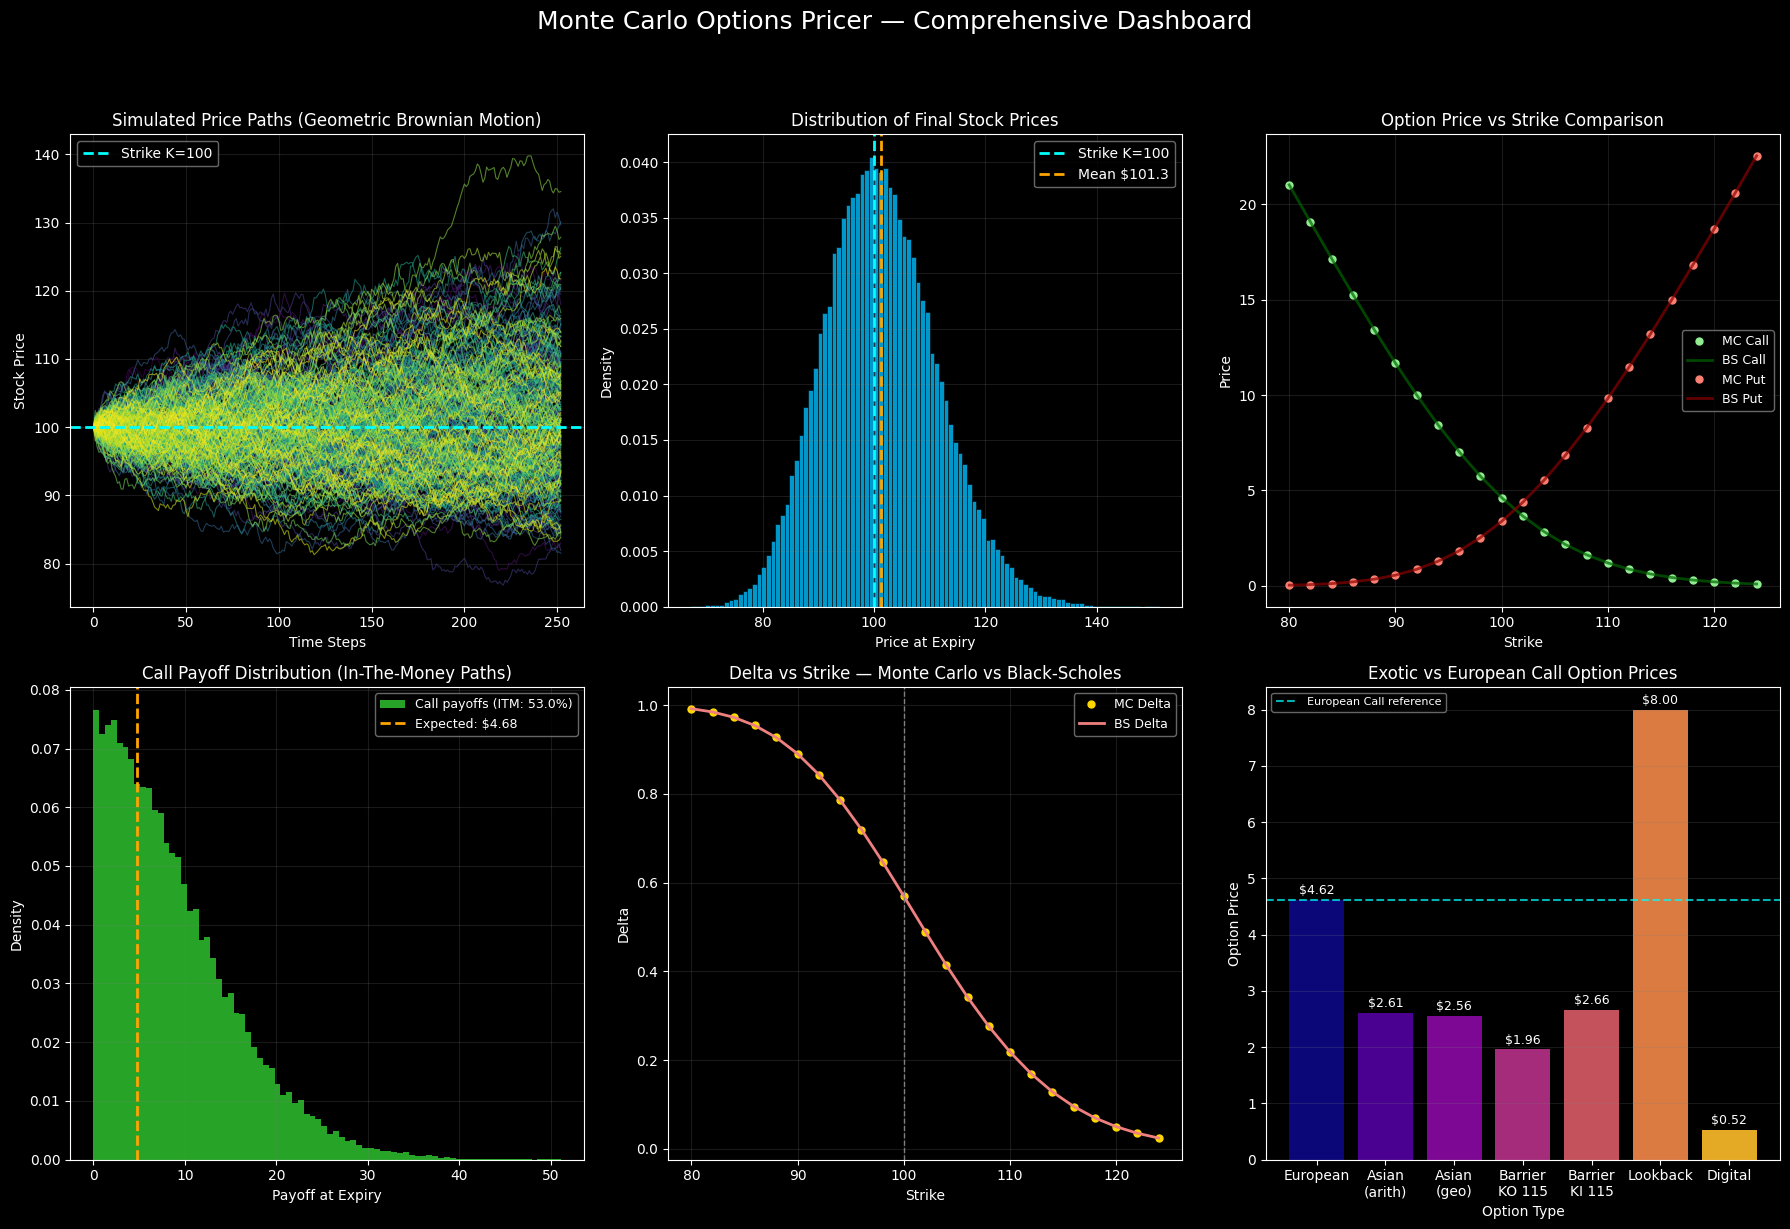

In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as colors

# ============================================================
# Visual dashboard
# ============================================================

plt.style.use('dark_background') # Apply dark background style

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Define a colormap for paths to make them radially colorful
path_cmap = cm.viridis # Using viridis for perceptually uniform colors
num_paths_to_plot = 300 # Show more paths clearly

# 1 — Sample price paths
for i in range(num_paths_to_plot):
    # Assign color from colormap based on path index
    color = path_cmap(i / num_paths_to_plot)
    axes[0,0].plot(pricer.paths[:, i], color=color,
                   alpha=0.6, linewidth=0.8) # Increased visibility
axes[0,0].axhline(y=K, color='cyan', linewidth=2.0, # Changed color for visibility
                  linestyle='--', label=f'Strike K={K}')
axes[0,0].set_title('Simulated Price Paths (Geometric Brownian Motion)', color='white') # Title color
axes[0,0].set_xlabel('Time Steps', color='white') # Label color
axes[0,0].set_ylabel('Stock Price', color='white') # Label color
axes[0,0].tick_params(colors='white') # Tick color
axes[0,0].legend(fontsize=10, facecolor='black', edgecolor='gray') # Legend styling
axes[0,0].grid(True, alpha=0.2, color='gray') # Grid styling

# 2 — Final price distribution
final = pricer.paths[-1, :]
axes[0,1].hist(final, bins=100, color='deepskyblue', density=True, # Changed color
               alpha=0.8, edgecolor='black', linewidth=0.5) # Increased visibility
axes[0,1].axvline(x=K, color='cyan', linewidth=2.0,
                  linestyle='--', label=f'Strike K={K}')
axes[0,1].axvline(x=final.mean(), color='orange', linewidth=2.0,
                  linestyle='--', label=f'Mean ${final.mean():.1f}')
axes[0,1].set_title('Distribution of Final Stock Prices', color='white')
axes[0,1].set_xlabel('Price at Expiry', color='white')
axes[0,1].set_ylabel('Density', color='white')
axes[0,1].tick_params(colors='white')
axes[0,1].legend(fontsize=10, facecolor='black', edgecolor='gray')
axes[0,1].grid(True, alpha=0.2, color='gray')

# 3 — Option price vs strike
strikes   = np.arange(80, 125, 2)
mc_calls  = [pricer.european(k, 'call')[0] for k in strikes]
bs_calls  = [pricer.bs_price(k, 'call') for k in strikes]
mc_puts   = [pricer.european(k, 'put')[0] for k in strikes]
bs_puts   = [pricer.bs_price(k, 'put') for k in strikes]

axes[0,2].plot(strikes, mc_calls, 'o', color='lightgreen', # Changed color
               markersize=5, label='MC Call')
axes[0,2].plot(strikes, bs_calls, '-', color='darkgreen',
               linewidth=2.0, alpha=0.7, label='BS Call')
axes[0,2].plot(strikes, mc_puts,  'o', color='salmon', # Changed color
               markersize=5, label='MC Put')
axes[0,2].plot(strikes, bs_puts,  '-', color='darkred',
               linewidth=2.0, alpha=0.7, label='BS Put')
axes[0,2].set_title('Option Price vs Strike Comparison', color='white')
axes[0,2].set_xlabel('Strike', color='white')
axes[0,2].set_ylabel('Price', color='white')
axes[0,2].tick_params(colors='white')
axes[0,2].legend(fontsize=9, facecolor='black', edgecolor='gray')
axes[0,2].grid(True, alpha=0.2, color='gray')

# 4 — Payoff distributions
call_payoffs = np.maximum(final - K, 0)
put_payoffs  = np.maximum(K - final, 0)

axes[1,0].hist(call_payoffs[call_payoffs > 0], bins=80,
               color='limegreen', alpha=0.8, density=True, # Changed color
               label=f'Call payoffs (ITM: {(final>K).mean()*100:.1f}%)')
axes[1,0].axvline(x=call_payoffs.mean()*np.exp(pricer.r*pricer.T),
                  color='orange', linewidth=2.0,
                  linestyle='--', label=f'Expected: ${call_payoffs.mean():.2f}')
axes[1,0].set_title('Call Payoff Distribution (In-The-Money Paths)', color='white')
axes[1,0].set_xlabel('Payoff at Expiry', color='white')
axes[1,0].set_ylabel('Density', color='white')
axes[1,0].tick_params(colors='white')
axes[1,0].legend(fontsize=9, facecolor='black', edgecolor='gray')
axes[1,0].grid(True, alpha=0.2, color='gray')

# 5 — Delta across strikes (MC vs BS)
deltas_mc = []
deltas_bs = []
for k in strikes:
    # Re-initialize pricer for each strike to reset paths for delta calculation (finite diff)
    p = MonteCarloPricer(pricer.S0, pricer.r, pricer.sigma,
                          pricer.T, 50000, pricer.n_steps, pricer.seed)
    g = p.greeks(k, 'call')
    deltas_mc.append(g['delta'])
    d1 = (np.log(pricer.S0/k) + (pricer.r + 0.5*pricer.sigma**2)*pricer.T) / \
         (pricer.sigma*np.sqrt(pricer.T))
    deltas_bs.append(norm.cdf(d1))

axes[1,1].plot(strikes, deltas_mc, 'o', color='gold', # Changed color
               markersize=5, label='MC Delta')
axes[1,1].plot(strikes, deltas_bs, '-', color='lightcoral',
               linewidth=2.0, label='BS Delta')
axes[1,1].axvline(x=pricer.S0, color='gray', linewidth=1.0, linestyle='--')
axes[1,1].set_title('Delta vs Strike — Monte Carlo vs Black-Scholes', color='white')
axes[1,1].set_xlabel('Strike', color='white')
axes[1,1].set_ylabel('Delta', color='white')
axes[1,1].tick_params(colors='white')
axes[1,1].legend(fontsize=9, facecolor='black', edgecolor='gray')
axes[1,1].grid(True, alpha=0.2, color='gray')

# 6 — Exotic vs European prices
option_names  = ['European', 'Asian\n(arith)', 'Asian\n(geo)',
                  'Barrier\nKO 115', 'Barrier\nKI 115',
                  'Lookback', 'Digital']
option_prices = [eu_call, as_arith, as_geo,
                  bar_ko, bar_ki, lb_call, dig_call]

# Use a professional colormap for the bars
bar_cmap = cm.plasma # Using plasma colormap
bar_colors = [bar_cmap(i/len(option_names)) for i in range(len(option_names))]

bars = axes[1,2].bar(option_names, option_prices, color=bar_colors, alpha=0.9)
axes[1,2].axhline(y=eu_call, color='cyan', linewidth=1.5,
                  linestyle='--', alpha=0.7, label='European Call reference')
for bar, price in zip(bars, option_prices):
    axes[1,2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                    f'${price:.2f}', ha='center', va='bottom', fontsize=9, color='white')
axes[1,2].set_title('Exotic vs European Call Option Prices', color='white')
axes[1,2].set_xlabel('Option Type', color='white')
axes[1,2].set_ylabel('Option Price', color='white')
axes[1,2].tick_params(colors='white')
axes[1,2].legend(fontsize=8, facecolor='black', edgecolor='gray')
axes[1,2].grid(True, alpha=0.2, axis='y', color='gray')

plt.suptitle('Monte Carlo Options Pricer — Comprehensive Dashboard', fontsize=18, y=1.02, color='white')
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

plt.style.use('default') # Reset matplotlib style to default

### Interactive Simulated Price Paths

Here is an interactive version of the simulated price paths. You can hover over individual paths to see their values, zoom in and out, and pan across the time series.

In [ ]:
import plotly.express as px

# Prepare data for Plotly Express
# price_paths is (n_steps + 1, n_sims)

time_steps = np.arange(pricer.n_steps + 1)

# Create a list of DataFrames, one for each simulation path
plot_data = []
for i in range(pricer.n_sims):
    df_path = pd.DataFrame({
        'Time Step': time_steps,
        'Stock Price': pricer.paths[:, i],
        'Simulation': f'Path {i+1}'
    })
    plot_data.append(df_path)

# Concatenate all DataFrames into a single long-format DataFrame
df_plotly = pd.concat(plot_data)

# Create the interactive line plot
fig = px.line(df_plotly,
              x='Time Step',
              y='Stock Price',
              color='Simulation',
              title='Interactive Simulated Price Paths (Hover, Zoom, Pan)',
              labels={'Time Step': 'Time Steps', 'Stock Price': 'Stock Price'},
              height=600)

# Customize layout for better dark theme integration and visibility
fig.update_layout(
    template='plotly_dark', # Use dark theme
    showlegend=False,      # Hide legend for individual paths as there are too many
    hovermode='x unified'  # Improve hover experience
)

# Add a horizontal line for the strike price K
fig.add_hline(y=K, line_dash='dash', line_color='cyan', annotation_text=f'Strike K={K}', annotation_position='bottom right')

fig.show()